In [7]:
import os
import importlib.util

spec = importlib.util.spec_from_file_location("vv2rgb", os.path.join('vv2rgb', "PL_4.py"))

s22rgb = importlib.util.module_from_spec(spec)
spec.loader.exec_module(s22rgb)

In [8]:
from osgeo import gdal
import matplotlib.pyplot as plt
import numpy as np

def convert_db_norm(file_path, show_plot=False):
    s2_ds = gdal.Open(file_path)

    s2 = np.empty((s2_ds.RasterYSize, s2_ds.RasterXSize, s2_ds.RasterCount))
    for i in range(s2.shape[2]):
        s2[:, :, i] = s2_ds.GetRasterBand(i + 1).ReadAsArray()
        
    rgb = s22rgb.convert(s2)

    if show_plot is True:
        plt.figure(figsize=(20, 5))
        plt.subplot(1, 4, 1)
        plt.imshow(rgb, vmin=0, vmax=255)
        plt.subplot(1, 4, 2)
        plt.imshow(rgb[:, :, 0], cmap="gray", vmin=0, vmax=255)
        plt.subplot(1, 4, 3)
        plt.imshow(rgb[:, :, 1], cmap="gray", vmin=0, vmax=255)
        plt.subplot(1, 4, 4)
        plt.imshow(rgb[:, :, 2], cmap="gray", vmin=0, vmax=255)
        plt.show()

    return rgb

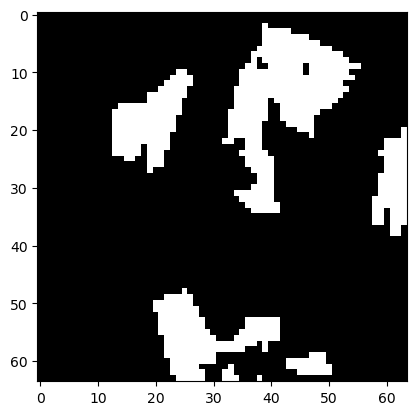

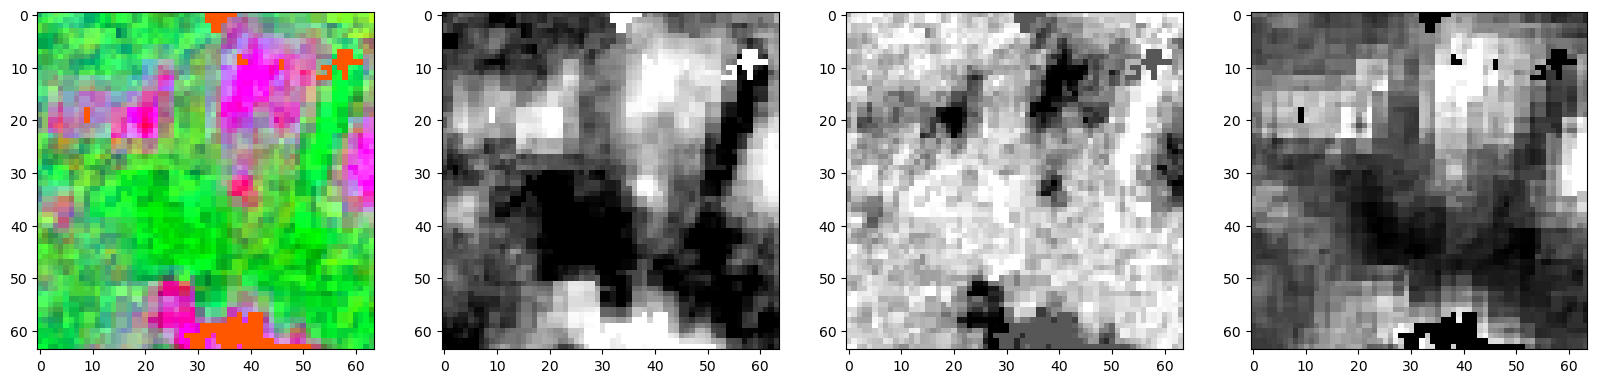

In [9]:
ds = gdal.Open(r'data/g8_xoff_0_yoff_0_MASK.tif')
mask = ds.GetRasterBand(1).ReadAsArray()

plt.imshow(mask, cmap="gray")
_ = convert_db_norm(r'data/g8_xoff_0_yoff_0_S2.tif', True)